In [1]:
import sys
import git
import pathlib

# Set up the PROJ_ROOT variable
PROJ_ROOT_PATH = pathlib.Path(git.Repo('.', search_parent_directories=True).working_tree_dir)
PROJ_ROOT =  str(PROJ_ROOT_PATH)
if PROJ_ROOT not in sys.path:
    sys.path.append(PROJ_ROOT)

# Explicitly add the current notebook's directory
CURRENT_DIR = str(pathlib.Path().absolute())
if CURRENT_DIR not in sys.path:
    sys.path.insert(0, CURRENT_DIR)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors
%matplotlib inline  
# Set the float display format to scientific notation
pd.set_option('display.float_format', '{:.2e}'.format)
# pd.set_option('display.float_format', '{:.2f}'.format)
# pd.set_option('display.precision', 2)

import yaml

In [3]:
# from library.utils import watts_to_dbm, dBm2Watts, get_OPERATION_COUNTS, get_DUTY_CYCLES, df_float_formatter, df_int_formatter
from library.utils import watts_to_dbm, dBm2Watts,  df_float_formatter, df_int_formatter

# Get Workload Specifications

In [4]:
from library.workload_specs import ESM_CX_a as WORKLOAD

# Get Configuration Parameters

In [5]:
config_name = pathlib.Path.cwd().name # based on current directory

for file in pathlib.Path(CURRENT_DIR).iterdir():
    if file.suffix == ".yaml":
        config_file = pathlib.Path(file)

# Get configuration parameters for dilution fridge, cables, attenuators, components
from library.utils import load_config
config = load_config(config_file)


FRIDGE_NAME = config["FRIDGE_NAME"] 

QUBIT_FREQ     = config["QUBIT_FREQ"]
QUBIT_COUPLING = config["QUBIT_COUPLING"]

QUBIT_TYPES = config["QUBIT_TYPES"]

OPERATIONS = config["OPERATIONS"]
READOUT_GROUP_SIZE = config["READOUT_GROUP_SIZE"]
DRIVE_MUX   = config["DRIVE_MUX"]
READIN_MUX   = config["READIN_MUX"]

CABLE_TYPES = config["CABLE_TYPES"]
CABLE_CONFIG_NAMES = config["CABLE_CONFIG_NAMES"]  
ATT_CONFIG = config["ATT_CONFIG"]  
COMP_CONFIG_NAMES = config["COMP_CONFIG_NAMES"]  
ACTIVATION_MATRIX = config["ACTIVATION_MATRIX"] 

if "DC_PARAMS" in config.keys():
    DC_PARAMS = config["DC_PARAMS"]
    R_4K = DC_PARAMS["R_4K"] 
    R_Still = DC_PARAMS["R_Still"] 
    R_CP = DC_PARAMS["R_CP"] 
    R_MXC = DC_PARAMS["R_MXC"]  
    I_BIAS = DC_PARAMS["I_BIAS"]  
    I_2Q = DC_PARAMS["I_2Q"] #NREQ
else:
    R_4K = None
    R_Still = None
    R_CP = None
    R_MXC = None
    I_BIAS = None
    I_2Q = None

In [6]:
import importlib
module = importlib.import_module("configure")
get_NO_OF_CABLES = module.get_NO_OF_CABLES
get_MXC_POWER = module.get_MXC_POWER
get_MUX_RATIO = module.get_MUX_RATIO

### Operation Duty Cycles

In [7]:
# Latency of Operations
LATENCY = WORKLOAD["LATENCY"]
LATENCY_DF = pd.DataFrame(LATENCY, index=["Latency (ns)"])

# Number of Operations
OPERATION_COUNTS = WORKLOAD["OPERATION_COUNT"]
OPERATION_COUNTS_DF = pd.DataFrame(OPERATION_COUNTS, index=["No. of Operations"])

# Mulitplexing Ratio
MUX_RATIO = get_MUX_RATIO(OPERATIONS, DRIVE_MUX, READIN_MUX, READOUT_GROUP_SIZE)
MUX_RATIO_DF = pd.DataFrame(MUX_RATIO, index=["Multiplexing Ratio"])

odc_df = pd.concat([LATENCY_DF, OPERATION_COUNTS_DF, MUX_RATIO_DF])
odc_df = odc_df.replace(0.0, '-')
odc_df

,1Q,2Q,READOUT,IDLE,TOTAL
Latency (ns),4.27e+01,7.11e+01,1.00e+02,-,1.10e+03
No. of Operations,4.00e+00,1.60e+01,4.00e+00,-,NaN
Multiplexing Ratio,1.00e+00,1.00e+00,2.50e-01,1.00e+00,NaN


### Required Power at MXC

In [8]:
MXC_POWER = get_MXC_POWER(R_MXC, I_2Q, QUBIT_FREQ, QUBIT_COUPLING)

MXC_POWER_DF = pd.DataFrame(MXC_POWER).T
MXC_POWER_DF = MXC_POWER_DF.fillna("n/a")
print("Power Requirements at MXC in dBm")
print("=========================")
MXC_POWER_DF

Power Requirements at MXC in dBm


,1Q,2Q,READOUT,IDLE
DRIVE,-7.10e+01,-6.60e+01,n/a,n/a
PUMP,n/a,n/a,-5.50e+01,n/a
READOUT_PIN,n/a,n/a,-1.20e+02,n/a
READOUT_POUT,n/a,n/a,n/a,n/a
AMP_BIAS,n/a,n/a,n/a,n/a
DC_TERMINAL,n/a,n/a,n/a,n/a


### Sanity check for ACTIVATION MATRIX

In [9]:
from library.utils import check_activation_matrix
check_activation_matrix(ACTIVATION_MATRIX, OPERATIONS);

In [10]:
# Get dilution refrigerator parameters
from library.fridges import TEMP_STAGES, FRIDGE_LIBRARY
cooling_power_budget = FRIDGE_LIBRARY[FRIDGE_NAME]

# Create a summary of the fridge/cable/attenuator configuration
NO_OF_CABLES = get_NO_OF_CABLES(QUBIT_TYPES, QUBIT_FREQ, QUBIT_COUPLING, READOUT_GROUP_SIZE)

summary = {}
for cable_type in CABLE_TYPES:
    summary[cable_type] = {}
    summary[cable_type]["Operations"] = ", ".join(x for x in ACTIVATION_MATRIX[cable_type])
    summary[cable_type]["No. of Cables"] = NO_OF_CABLES[cable_type]
    for temp_stage in TEMP_STAGES:
        if (CABLE_CONFIG_NAMES[cable_type][temp_stage] is None):
            cb_name = ""
        else:
            cb_name = CABLE_CONFIG_NAMES[cable_type][temp_stage]

        if ATT_CONFIG[cable_type][temp_stage] == 0:
            att_val = ""
        else:
            att_val = f"({ATT_CONFIG[cable_type][temp_stage]} dB)"        
        summary[cable_type][temp_stage] = f"{cb_name} {att_val}"
        
summary_DF = pd.DataFrame(summary)

summary_DF = summary_DF.T


summary_DF.loc["COOLING POWER (Watts)"] = [None,None] + list(cooling_power_budget.values()) 
summary_DF = summary_DF.fillna(" ")
print("Fridge/Cable/Attenuator Configuration")
print(f"{FRIDGE_NAME=}")
print(QUBIT_TYPES)
print(f"{READOUT_GROUP_SIZE=}")
summary_DF = summary_DF.drop(columns=["RT", "50K"])
print("=====================================")
summary_DF

Fridge/Cable/Attenuator Configuration
FRIDGE_NAME='XLD1000SL_v3'
{'DATA': 4, 'ANCILLA': 4}
READOUT_GROUP_SIZE=4


,Operations,No. of Cables,4K,Still,CP,MXC
DRIVE,"1Q, 2Q",8,Ag (20 dB),Ag (10 dB),Ag (10 dB),Ag (20 dB)
PUMP,READOUT,2.00e+00,Ag (20 dB),Ag,Ag (10 dB),Ag (20 dB)
READOUT_PIN,READOUT,2.00e+00,Ag (20 dB),Ag (10 dB),Ag (10 dB),Ag (20 dB)
READOUT_POUT,READOUT,2.00e+00,Ag,NbTi,NbTi,NbTi
AMP_BIAS,IDLE,2.00e+00,HEMT_Bias_Mn,,,
DC_TERMINAL,IDLE,2.00e+00,,NbTi,NbTi,NbTi
COOLING POWER (Watts),,,7.00e-01,7.00e-03,1.00e-03,3.00e-05


In [11]:
# Create a summary of the component configuration
COMP_CONFIG_NAMES_DF = pd.DataFrame(COMP_CONFIG_NAMES).T
COMP_CONFIG_NAMES_DF.fillna("-", inplace = True)
print("Component Configuration")
print("=======================")
COMP_CONFIG_NAMES_DF

Component Configuration


,RT,50K,4K,Still,CP,MXC
DRIVE,-,-,-,-,-,-
PUMP,-,-,-,-,-,-
READOUT_PIN,-,-,-,-,-,-
READOUT_POUT,-,-,-,-,-,-
AMP_BIAS,-,-,HEMT_8G,-,-,-
DC_TERMINAL,-,-,-,-,-,-


In [12]:
# Create a dictionary with cable classes instantiated
from library.cables import get_cable_config
CABLE_CONFIG = get_cable_config(CABLE_CONFIG_NAMES)

In [13]:
# Create a dictionary with component  classes instantiated
from library.components import get_comp_config
COMP_CONFIG = get_comp_config(COMP_CONFIG_NAMES)

In [14]:
# Add ohmic resistors
from library.cables import R_Cu_4K, R_Cu_50K, R_Manganin_4K, R_Manganin_50K
from library.components import add_ohmic_resistors_amp_at_4K,add_ohmic_resistors_amp_at_50K, add_flux_coupler_DC_resistance

# update COMP_CONFIG with ohmic resistors at 4K and 50K for amplifier at 4K
COMP_CONFIG = add_ohmic_resistors_amp_at_4K(CABLE_CONFIG_NAMES, COMP_CONFIG)
# update COMP_CONFIG with ohmic resistors at 50K for amplifier at 50K
if 'AMP_BIAS_50K' in CABLE_CONFIG_NAMES.keys():
    COMP_CONFIG = add_ohmic_resistors_amp_at_50K(CABLE_CONFIG_NAMES, COMP_CONFIG)

# Set up Resistances in `FLUX_BIAS` and `COUPLER_BIAS` lines

In [15]:
# update COMP_CONFIG with DC resistors for flux/coupler-bias lines
COMP_CONFIG = add_flux_coupler_DC_resistance(COMP_CONFIG,
                                           QUBIT_FREQ, 
                                           QUBIT_COUPLING, 
                                           R_4K, R_Still, R_CP, R_MXC)

# Passive Heat Load (PHL) Calculation

In [16]:
from collections import defaultdict
PHL = defaultdict(lambda: defaultdict(dict)) # Passive Heat Load Dictionary
# PHL[cable_type][temp_stage] = total PHL due to that cable_type
for cable_type in CABLE_TYPES:
    for temp_stage in TEMP_STAGES:
        cable_heat_load = 0.0
        if CABLE_CONFIG[cable_type][temp_stage] is not None:
            if CABLE_CONFIG[cable_type][temp_stage].PHL_dict[temp_stage] is not None:
                cable_heat_load = CABLE_CONFIG[cable_type][temp_stage].PHL_dict[temp_stage] *  NO_OF_CABLES[cable_type]
        PHL[cable_type][temp_stage] = cable_heat_load    

In [17]:
PHL_DF = pd.DataFrame(PHL).T
print("Passive Heat Load (in Watts)")
print("============================")
PHL_DF

Passive Heat Load (in Watts)


,RT,50K,4K,Still,CP,MXC
DRIVE,0.00e+00,2.16e-02,6.40e-03,4.32e-05,2.32e-06,4.72e-08
PUMP,0.00e+00,5.40e-03,1.60e-03,1.08e-05,5.80e-07,1.18e-08
READOUT_PIN,0.00e+00,5.40e-03,1.60e-03,1.08e-05,5.80e-07,1.18e-08
READOUT_POUT,0.00e+00,5.40e-03,1.60e-03,1.08e-06,5.80e-08,1.18e-09
AMP_BIAS,0.00e+00,4.08e-03,2.34e-04,0.00e+00,0.00e+00,0.00e+00
DC_TERMINAL,0.00e+00,0.00e+00,0.00e+00,1.08e-06,5.80e-08,1.18e-09


# Active Heat Load (AHL) Calculation

## AHL from Attenuator Dissipation

In [18]:
from library.cables import cable_attenuator_dissipation

In [19]:
ATT_DISSIPATION = defaultdict(lambda: defaultdict(dict))
for cable_type in CABLE_TYPES:
    # Get the attenuator configuration for the cable
    cable_attenuator_config = ATT_CONFIG[cable_type]
    # Calculate power dissipation for each type of operation
    # This is the power dissipation for a SINGLE cable
    # Power dissipation in is dBm and assumes 100% duty cycle
    # This is NOT the final power dissipation by the attenuators
    for operation in OPERATIONS:
        ATT_DISSIPATION[cable_type][operation] = cable_attenuator_dissipation(cable_attenuator_config, MXC_POWER[cable_type][operation])

# Visualization using Dataframe
# Convert the nested dictionary to a list of records
records = []
for cable_type, operations in ATT_DISSIPATION.items():
    for operation, temp_stages in operations.items():
        # Start with identifying columns: cable_type and operation
        record = {'CABLE': cable_type, 
                  'OPERATION': operation}
        # Add all temperature stages and their values
        record.update(temp_stages)
        records.append(record)
# Create DataFrame from records
ATT_DISSIPATION_DF = pd.DataFrame(records)
# Set a multi-index with cable_type as the top level and operation as the sub-level
ATT_DISSIPATION_DF.set_index(['CABLE', 'OPERATION'], inplace=True)

print("Power Dissipation by Attenuators (in dBm) assuming 100% duty cycle")
print("==================================================================")
mask = ~((ATT_DISSIPATION_DF.isna()) | (ATT_DISSIPATION_DF == 0)).all(axis=1)
ATT_DISSIPATION_DF = ATT_DISSIPATION_DF[mask]
desired_cols = ["50K","4K", "Still", "CP", "MXC"]
ATT_DISSIPATION_DF = ATT_DISSIPATION_DF.reindex(columns=desired_cols)
ATT_DISSIPATION_DF.style.format(df_int_formatter)

Power Dissipation by Attenuators (in dBm) assuming 100% duty cycle


# Total Heat Load (THL)

In [20]:
THL = defaultdict(lambda: defaultdict(dict))
# THL[cable_type][temp_stage][component][operation]
# THL[cable_type][temp_stage][PASSIVE][IDLE]

In [21]:
# Active Heat Load

# The heat load arises either from components at the stage or due to attenuators on that stage
# However, attenuators dissipate heat only when the cable is active i.e., the duty cycle of the operation being performed using the cable affects the heat dissipated.
# Some components (amplifiers and their respective ohmic resistances) are always ON and dissipate heat at all times
# Some components (ohmic resistance for flux qubits) dissipate heat depending on the operation

In [22]:
for cable_type in CABLE_TYPES:
    for temp_stage in TEMP_STAGES:
        
        # components in each cable at each temperature stage
        component_list = COMP_CONFIG[cable_type][temp_stage]
        if component_list is not None:
                for component in component_list:
                        THL[cable_type][temp_stage][component.name]={}
        # Add key for attenuator component
        THL[cable_type][temp_stage]["ATT"]={}

        # Include passive heat load
        THL[cable_type][temp_stage]["PASSIVE"]={}
        THL[cable_type][temp_stage]["PASSIVE"]["IDLE"] = PHL[cable_type][temp_stage]
                            
        for operation in OPERATIONS:
            # Some cable operations (e.g., Readout) are multiplexed. 
            # So the actual no. of cable activations required is only a fraction of the total required number of operations
            # This fraction is the MUX_RATIO for that operation
            # effective_no_of_ops represents the total number of times a particular cable is activated in totality 
            # (regardless of how many cables are present)
            # In other words, if we assume there was only one cable of a certain type, effective_no_of_ops represents how
            # many times it is activated
            # For e.g., assuming there are 8 DRIVE cables and each cable is activated 3 times for a 1Q operation.
            # This is equivalent to 1 DRIVE cable being activated 8*3=24 times for 1Q gates.
            effective_no_of_ops = MUX_RATIO[operation] * OPERATION_COUNTS[operation]
            # Operations are active for only a fraction of the total code cycle duration
            # This duty cycle is taken into consideration by `operation_active_fraction`
            operation_active_fraction = effective_no_of_ops  * LATENCY[operation]/LATENCY["TOTAL"]

            # Active Load from Attenuators: convert to Watts
            attn_dissipation = dBm2Watts(ATT_DISSIPATION[cable_type][operation][temp_stage])
            THL[cable_type][temp_stage]["ATT"][operation] = attn_dissipation * operation_active_fraction
            # NOTE: This value DOES NOT need to be mulitplied with NO_OF_CABLES[cable_type] because it is already considered
            # during the calculation of effective_no_of_ops

            # Active Load from components
            if component_list is not None:
                for component in component_list:
                    if operation in ACTIVATION_MATRIX[cable_type]:
                        if operation != "IDLE":
                            component_power = component.power_dissipation(operation, MXC_POWER) * operation_active_fraction
                            # NOTE: This value DOES NOT need to be mulitplied with NO_OF_CABLES[cable_type] because it is already considered
                            # during the calculation of effective_no_of_ops
                            THL[cable_type][temp_stage][component.name][operation] = component_power
                        elif operation == "IDLE":
                            no_of_components = NO_OF_CABLES[cable_type]
                            component_power = component.power_dissipation(operation, MXC_POWER) * no_of_components
                            # NOTE: This value MUST BE mulitplied with NO_OF_CABLES[cable_type] because the component is always ON
                            # and scales with the number of components
                            THL[cable_type][temp_stage][component.name][operation] = component_power

### Redirecting TWPA Power Dissipation from MXC to 4K
The 20dB attenuation at MXC is achieved via circulator. This power can be redirected to the 4K stage for dissipation

In [23]:
# Redirecting TWPA Power Dissipation from MXC to 4K
THL['PUMP']['4K']['ATT']['READOUT'] = THL['PUMP']['4K']['ATT']['READOUT'] + THL['PUMP']['MXC']['ATT']['READOUT'] 
THL['PUMP']['MXC']['ATT']['READOUT'] = 0.0 

In [24]:
# Visualizing Active Heat Load as table
rows = []
for cable_type, temp_dict in THL.items():
    for temp_stage, comp_dict in temp_dict.items():
        for comp, operation_dict in comp_dict.items():
            for operation, power in operation_dict.items():
                rows.append((cable_type, comp, operation, temp_stage, power))
    
# Create DataFrame
df = pd.DataFrame(rows, columns=["Cable", "Component", "Operation", "Temp", "Power"])
            
# Pivot into desired table
table = df.pivot_table(
    index=["Cable", "Component", "Operation"], 
    columns="Temp", 
    values="Power"
)
THL_DF = table.fillna(0)

desired_cols = ["50K","4K", "Still", "CP", "MXC"]
THL_DF = THL_DF.reindex(columns=desired_cols)


# Get the order in which to rearrange the rows
from library.constants import ORDER_DICT

# Rearrange rows
rows = THL_DF.index.get_level_values("Cable").unique().tolist()
reordered_rows = sorted(rows, key=lambda x: ORDER_DICT[x])
THL_DF = THL_DF.reindex(reordered_rows, level=0)

# Drop rows where *every* entry is NaN, 0 or 0.0
mask = ~(THL_DF == 0).all(axis=1)
THL_DF = THL_DF[mask]

THL_DF.style.format(df_float_formatter)

## Normalized Heat Load and Qubit Scaling

In [25]:
QUBIT_GROUP_SIZE = QUBIT_TYPES["DATA"] + QUBIT_TYPES["ANCILLA"]
NO_OF_QUBIT_GROUPS = int(10_000/QUBIT_GROUP_SIZE)
TOTAL_NO_OF_QUBITS = QUBIT_GROUP_SIZE * NO_OF_QUBIT_GROUPS # does not include the coupler qubits

In [26]:
# Calculate how many qubits are supported at each temperature stage

# Cooling power at each temperature stage
cooling_powers = np.array([cooling_power_budget[temp_stage] for temp_stage in ['50K','4K', 'Still', 'CP', 'MXC']])

# Total heat load at each temperature stage
ALL_DF = THL_DF[['50K', '4K', 'Still', 'CP', 'MXC']].copy()
ALL_DF.loc["Total"] = ALL_DF.sum()
total_load = np.array(ALL_DF.loc["Total"].tolist()) # includes heat load due to coupler qubits if any

# No. of qubits supported by each temperature stage
possible_groups = np.floor(cooling_powers/total_load).astype(int)
possible_physical_qubits = possible_groups * QUBIT_GROUP_SIZE
physical_qubits_dict = dict(zip(['50K', '4K', 'Still', 'CP', 'MXC'], possible_physical_qubits))
print("The number of qubits supported at each temperature stage is:")
print(physical_qubits_dict)

# Display the bottleneck temperature stage
bottleneck = min(physical_qubits_dict, key= physical_qubits_dict.get)
print(f"\nThe bottleneck is at: {bottleneck}")

The number of qubits supported at each temperature stage is:
{'50K': 5472, '4K': 192, 'Still': 800, 'CP': 1920, 'MXC': 2384}

The bottleneck is at: 4K


In [27]:
no_of_groups = np.floor(cooling_powers/total_load).astype(int)
max_no_of_groups = min(no_of_groups)
max_heat_loads = total_load * max_no_of_groups
frac_of_cooling_power = np.round(max_heat_loads/cooling_powers * 100, 2)
frac_of_cooling_power_dict = dict(zip(['4K', 'Still', 'CP', 'MXC'], frac_of_cooling_power))

max_supported_qubits = max_no_of_groups * QUBIT_GROUP_SIZE
print(f"{max_supported_qubits=}")
print(frac_of_cooling_power_dict)

max_supported_qubits=192
{'4K': 3.5, 'Still': 96.94, 'CP': 23.89, 'MXC': 9.97}


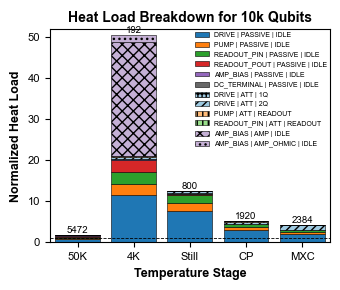

Cable        DRIVE     PUMP READOUT_PIN READOUT_POUT AMP_BIAS DC_TERMINAL  \
Component  PASSIVE  PASSIVE     PASSIVE      PASSIVE  PASSIVE     PASSIVE   
Operation     IDLE     IDLE        IDLE         IDLE     IDLE        IDLE   
Temp                                                                        
50K       9.00e-01 2.25e-01    2.25e-01     2.25e-01 1.70e-01    0.00e+00   
4K        1.14e+01 2.86e+00    2.86e+00     2.86e+00 4.17e-01    0.00e+00   
Still     7.71e+00 1.93e+00    1.93e+00     1.93e-01 0.00e+00    1.93e-01   
CP        2.90e+00 7.25e-01    7.25e-01     7.25e-02 0.00e+00    7.25e-02   
MXC       1.97e+00 4.92e-01    4.92e-01     4.92e-02 0.00e+00    4.92e-02   

Cable        DRIVE              PUMP READOUT_PIN AMP_BIAS            
Component      ATT               ATT         ATT      AMP AMP_OHMIC  
Operation       1Q       2Q  READOUT     READOUT     IDLE      IDLE  
Temp                                                                 
50K       0.00e+00 0.00e+00 0.00e+00    0.00e+00 0.00e+00  7.99e-02  
4K        2.20e-02 4.64e-01 5.14e-02    1.62e-07 2.79e+01  1.68e+00  
Still     2.20e-02 4.64e-01 0.00e+00    1.62e-07 0.00e+00  0.00e+00  
CP        1.54e-02 3.25e-01 3.59e-01    1.14e-07 0.00e+00  0.00e+00  
MXC       5.14e-02 1.08e+00 0.00e+00    3.79e-07 0.00e+00  0.00e+00

In [28]:
# --- Normalize the DataFrame ---
# Since the temperature stages are columns, we divide each column by its normalization factor.
NHL_DF = THL_DF.copy()
for temp_stage in NHL_DF.columns:
    NHL_DF[temp_stage] = (NHL_DF[temp_stage] * NO_OF_QUBIT_GROUPS)/cooling_power_budget[temp_stage]

# --- Prepare the DataFrame for plotting ---
# We want the X-axis to be the temperature stages.
# To do so, we transpose the DataFrame so that rows become the temperature stages.
df_plot = NHL_DF.T  # now rows: temperature stages; columns: MultiIndex (Component, Subcomponent)

# Prepare the title
# title = f"{NO_OF_QUBIT_GROUPS} Groups x {QUBIT_GROUP_SIZE} qubit per group = {TOTAL_NO_OF_QUBITS} qubits ({WORKLOAD['NAME']})"
title = "Heat Load Breakdown for 10k Qubits"
# Plot the dataframe
from library.utils import plot_heat_load
plot_heat_load(df_plot, title, config_name, physical_qubits_dict, legend_bbox=(1.0, 1.0))